<a href="https://colab.research.google.com/github/bhagyasree2004/MachineLearning_Module/blob/main/REGRESSION_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#REGRESSION MODEL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/50_Startups_dataset.csv')

In [ ]:
df.head()

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.30,136897.90,471784.20,New York,192261.93
1,1,162597.80,151377.69,443898.63,California,191792.16
2,2,153441.61,101145.65,407934.64,Florida,191050.49
3,3,144372.51,118671.95,383199.72,New York,182902.09
4,4,142107.44,91391.87,366168.52,Florida,166188.04


In [ ]:
#feature encoding
#x should be upto state   .x is everything without profit
x=df.iloc[:,:-1].values
x

array([[0, 165349.30000000002, 136897.9, 471784.2, 'New York'],
       [1, 162597.80000000002, 151377.69, 443898.63, 'California'],
       [2, 153441.61000000002, 101145.65, 407934.64, 'Florida'],
       [3, 144372.51, 118671.95, 383199.72, 'New York'],
       [4, 142107.44, 91391.87, 366168.52, 'Florida'],
       [5, 131877.0, 99814.81, 362861.46, 'New York'],
       [6, 134615.56, 147198.97, 127716.92, 'California'],
       [7, 130298.23, 145530.16, 323876.78, 'Florida'],
       [8, 120542.62, 148719.05000000002, 311613.39, 'New York'],
       [9, 123334.98, 108679.27, 304981.72, 'California'],
       [10, 101913.18, 110594.21, 229161.05, 'Florida'],
       [11, 100672.06, 91790.71, 249744.65, 'California'],
       [12, 93863.85, 127320.48, 249839.54, 'Florida'],
       [13, 91992.49, 135495.17, 252665.03, 'California'],
       [14, 119943.34, 156547.52000000002, 256513.02, 'Florida'],
       [15, 114523.71, 122616.94, 261776.33, 'New York'],
       [16, 78013.21, 121597.65, 264346.1

In [ ]:
#Y should be only profit
y=df.iloc[:,-1].values
y

array([192261.93, 191792.16, 191050.49, 182902.09, 166188.04, 156991.22,
       156122.61, 155752.7 , 152211.87, 149760.06, 146122.05, 144259.5 ,
       141585.62, 134307.45, 132602.75, 129917.14, 126993.03, 125370.47,
       124267.  , 122776.96, 118474.13, 111313.12, 110352.35, 108734.09,
       108552.14, 107404.44, 105733.64, 105008.41, 103282.48, 101004.74,
        99937.69,  97483.66,  97427.94,  96779.02,  96712.9 ,  96479.61,
        90708.29,  89949.24,  81229.16,  81005.86,  78240.01,  77798.93,
        71498.59,  69759.08,  65200.43,  64926.18,  49490.85,  42559.83,
        35673.51,  14681.5 ])

In [ ]:
import numpy as np
#one hot encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[4])],remainder='passthrough')
x = ct.fit_transform(x)

In [ ]:
x

array([[0.0, 0.0, 1.0, 0, 165349.30000000002, 136897.9, 471784.2],
       [1.0, 0.0, 0.0, 1, 162597.80000000002, 151377.69, 443898.63],
       [0.0, 1.0, 0.0, 2, 153441.61000000002, 101145.65, 407934.64],
       [0.0, 0.0, 1.0, 3, 144372.51, 118671.95, 383199.72],
       [0.0, 1.0, 0.0, 4, 142107.44, 91391.87, 366168.52],
       [0.0, 0.0, 1.0, 5, 131877.0, 99814.81, 362861.46],
       [1.0, 0.0, 0.0, 6, 134615.56, 147198.97, 127716.92],
       [0.0, 1.0, 0.0, 7, 130298.23, 145530.16, 323876.78],
       [0.0, 0.0, 1.0, 8, 120542.62, 148719.05000000002, 311613.39],
       [1.0, 0.0, 0.0, 9, 123334.98, 108679.27, 304981.72],
       [0.0, 1.0, 0.0, 10, 101913.18, 110594.21, 229161.05],
       [1.0, 0.0, 0.0, 11, 100672.06, 91790.71, 249744.65],
       [0.0, 1.0, 0.0, 12, 93863.85, 127320.48, 249839.54],
       [1.0, 0.0, 0.0, 13, 91992.49, 135495.17, 252665.03],
       [0.0, 1.0, 0.0, 14, 119943.34, 156547.52000000002, 256513.02],
       [0.0, 0.0, 1.0, 15, 114523.71, 122616.94, 261776.33

In [ ]:
#train test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
#prediction

#multiple linear regression

from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [ ]:
#prediction
y_pred=regressor.predict(x_test)
y_pred

array([101427.42959332, 140631.21132868, 140471.84002328,  67605.79003116,
       175097.57094571, 110837.34568363,  70259.22902027,  95306.23919936,
       115617.38758521, 166764.24888788,  90771.29296743,  85146.32032083,
       107011.70466922])

In [ ]:
y_test

array([103282.48, 144259.5 , 146122.05,  77798.93, 191050.49, 105008.41,
        81229.16,  97483.66, 110352.35, 166188.04,  96779.02,  96479.61,
       105733.64])

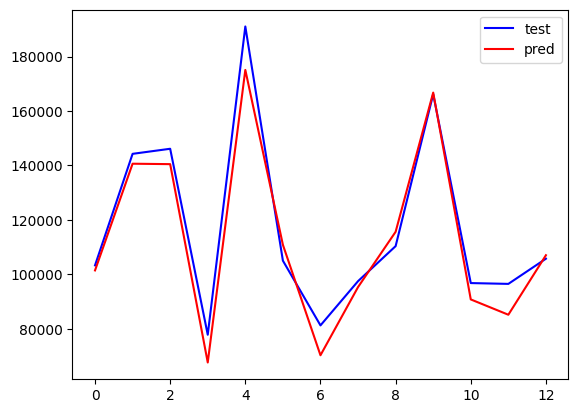

In [ ]:
plt.plot(y_test,color='blue',label='test')
plt.plot(y_pred,color='red',label='pred')
plt.legend()
plt.show()

In [ ]:
#pass the data which is not present in dataset

In [ ]:
df.head(1)

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.3,136897.9,471784.2,New York,192261.93


In [ ]:
data=[0.0,0.0,0.1,1.0,120000,400000,120000]

In [ ]:
#create pandas dataframe
df1=pd.DataFrame([data])

In [ ]:
df1

,0,1,2,3,4,5,6
0,0.0,0.0,0.1,1.0,120000,400000,120000


In [ ]:
#transform the data
df1=sc.transform(df1)

In [ ]:
#predictions
single=regressor.predict(df1)

In [ ]:
print(single)

[166224.87364959]


In [ ]:
df.head(1)

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.3,136897.9,471784.2,New York,192261.93


In [ ]:
#keep r & d and try to pred profit--> simple linear regression
# Simple Linear Regression

X = df[['R&D Spend']].values
Y= df['Profit'].values


In [ ]:
#train and test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=0)

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

Y_pred = regressor.predict(X_test)

print(Y_pred)

[104560.82466151 134156.73684656 135217.73082962  71940.25211233
 179267.7454832  109737.97468807  65389.11521965 100359.02792475
 111351.07673001 169578.5243176   95535.49411668  87431.40370649
 112491.73587783]


In [ ]:
#polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)



Predicted Profit:
[105732.91011148 135026.88439255 136053.37659304  71967.75456313
 177224.44079262 110949.2684821   64999.94987828 101470.6048029
 112566.6137224  168410.82435832  96545.91894137  88195.61779648
 113707.98679708]


In [ ]:
# 4. Apply Linear Regression
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(x_train_poly, y_train)

LinearRegression()

In [ ]:
# 5. Predict Profit
y_pred = regressor.predict(x_test_poly)

print("Predicted Profit:")
print(y_pred)


Predicted Profit:
[105732.91011148 135026.88439255 136053.37659304  71967.75456313
 177224.44079262 110949.2684821   64999.94987828 101470.6048029
 112566.6137224  168410.82435832  96545.91894137  88195.61779648
 113707.98679708]
